# Hello, World
*Measuring Manuscripts—Teaser session*

Welcome. If you have never written a line of code in your life, don't worry, you're in the right place. This course assumes you're starting from zero. Read ahead to understand what you're looking at.

> ### What if I know how to code already?
> In this and all other activites, optional exercises are provided for those with more coding experience. The goal is to push you to do a bit more on your own while those who are new to coding spend more time figuring things out. They're made for experienced coders, but everyone can try them out.

### What is this thing?
This is a **Jupyter notebook**: a single document that mixes ordinary text (like the words you're reading) with small blocks of Python code you can actually run. We're viewing it in **Google Colab**, a free service from Google that runs the code on Google's servers. So there is nothing to install and nothing can break on your own machine.

### What is Python?
**Python** is a *programming language*. It's one of the most widely used languages in the world for working with text and data, which is why we use it here. You won't need to learn python *per se*. Every activity in this course gives you a working template, and your job is to read it, run it, understand it, and adjust it (not necessarily in that order).

### What is a cell?
A notebook is built out of **cells**. *Text cells* (like this one) explain things. *Code cells* contain Python and have a ▶ button on the left. Click it to run the code in that cell, and the result appears immediately underneath.

### Why we work this way
1. **Nothing to install.** Colab runs in your web browser on any laptop—Mac, Windows, or Linux. Everyone is on the same setup, so we never lose time to installation problems.
2. **Explanation and code together.** You see the reasoning, the code, and the result stacked in one place—ideal for learning and for showing your work.
3. **Easy to save and share.** You can keep your own copy in Google Drive and send anyone a link.

---
Your only task right now is to prove your setup works. Click the ▶ Run all button in the toolbar, or press the ▶ button on each code cell, top to bottom. If you see output appear, you're ready for Day 1.


In [26]:
# A rite of passage: the classic first program everyone must write
print('Hello, World!')

Hello, World!


## 1. A text is (also) data

The Prologue from Canterbury Tales (some info about it, summary of what it is for beginners)

[Recitation in Middle English](https://www.youtube.com/watch?v=mVG77xTPH6E)

Not only is it a classic literary masterpiece, it is also a record of 

In [27]:
# A short, famous text: the Prologue from Canterbury Tales
text = """Whan that Aprille with his shoures soote,
The droghte of March hath perced to the roote,
And bathed every veyne in swich licóur
Of which vertú engendred is the flour;
Whan Zephirus eek with his swete breeth
Inspired hath in every holt and heeth
The tendre croppes, and the yonge sonne
Hath in the Ram his halfe cours y-ronne,
And smale foweles maken melodye,
That slepen al the nyght with open ye,
So priketh hem Natúre in hir corages,
Thanne longen folk to goon on pilgrimages,
And palmeres for to seken straunge strondes,
To ferne halwes, kowthe in sondry londes;
And specially, from every shires ende
Of Engelond, to Caunterbury they wende,
The hooly blisful martir for to seke,
That hem hath holpen whan that they were seeke."""

print(text)

Whan that Aprille with his shoures soote,
The droghte of March hath perced to the roote,
And bathed every veyne in swich licóur
Of which vertú engendred is the flour;
Whan Zephirus eek with his swete breeth
Inspired hath in every holt and heeth
The tendre croppes, and the yonge sonne
Hath in the Ram his halfe cours y-ronne,
And smale foweles maken melodye,
That slepen al the nyght with open ye,
So priketh hem Natúre in hir corages,
Thanne longen folk to goon on pilgrimages,
And palmeres for to seken straunge strondes,
To ferne halwes, kowthe in sondry londes;
And specially, from every shires ende
Of Engelond, to Caunterbury they wende,
The hooly blisful martir for to seke,
That hem hath holpen whan that they were seeke.


In [28]:
# Treat the text as a list of words
words = text.split()
print('Number of words:', len(words))
print('First five words:', words[:5])

Number of words: 128
First five words: ['Whan', 'that', 'Aprille', 'with', 'his']


## 2. The simplest analysis: which words repeat?

Compare the results for the most and least frequent words.

 - Do you notice anything interesting about them?
 - How might we measure the differences between them?

In [29]:
from collections import Counter
counts = Counter(w.lower().strip('.,;') for w in words)

print('5 most common words:')
for word, n in counts.most_common(5):
  print(f'{word!r:12} {n}')

# What about the least common words?
print('\n5 least common words:')
for word, n in counts.most_common()[-5:]:
  print(f'{word!r:12} {n}')



5 most common words:
'the'        8
'to'         6
'and'        6
'in'         5
'that'       4

5 least common words:
'martir'     1
'seke'       1
'holpen'     1
'were'       1
'seeke'      1


#### Zipf's law

A few words do most of the work, and a long tail of words appear only once. Rank the words from most to least frequent and the shape is strikingly regular. The first plot shows the ranked counts, with each word labeled. The second puts both axes on a log scale, where the curve straightens into a near-line. That regularity is **Zipf's law**, and it holds across languages.

However, in our example here, the log-log plot isn't quite as linear as we might hope based on Zipf's law. What could we do to fix that?

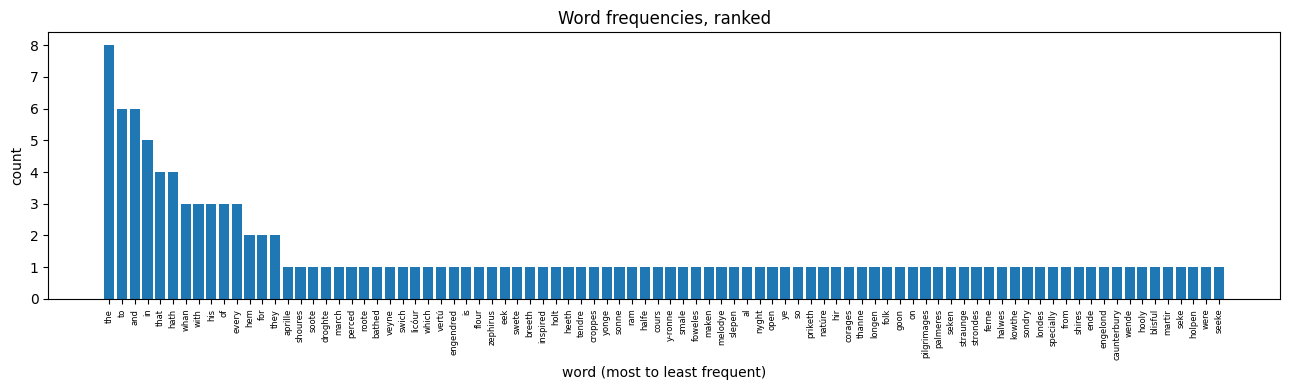

In [30]:
# Rank the words from most to least frequent
import matplotlib.pyplot as plt

ranked = counts.most_common()
labels = [word for word, n in ranked]
values = [n for word, n in ranked]

plt.figure(figsize=(13, 4))
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=90, fontsize=6)
plt.xlabel('word (most to least frequent)')
plt.ylabel('count')
plt.title('Word frequencies, ranked')
plt.tight_layout()
plt.show()

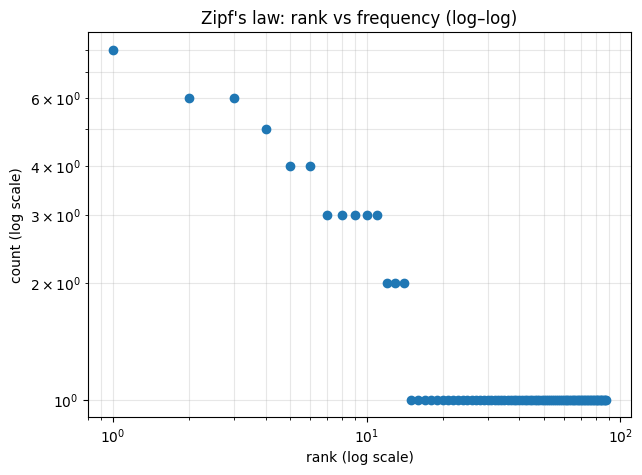

In [31]:
# The same data on log–log axes
import numpy as np

ranks = np.arange(1, len(values) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, values, marker='o', linestyle='none')
plt.xlabel('rank (log scale)')
plt.ylabel('count (log scale)')
plt.title("Zipf's law: rank vs frequency (log–log)")
plt.grid(True, which='both', alpha=0.3)
plt.show()

#### Zipf's law (continued)

The two figures above give us a glimpse into Zipf's law, but they're not as clean as we might like.

What if we try with much more data?

Loaded 267,739 words, 28,789 distinct.


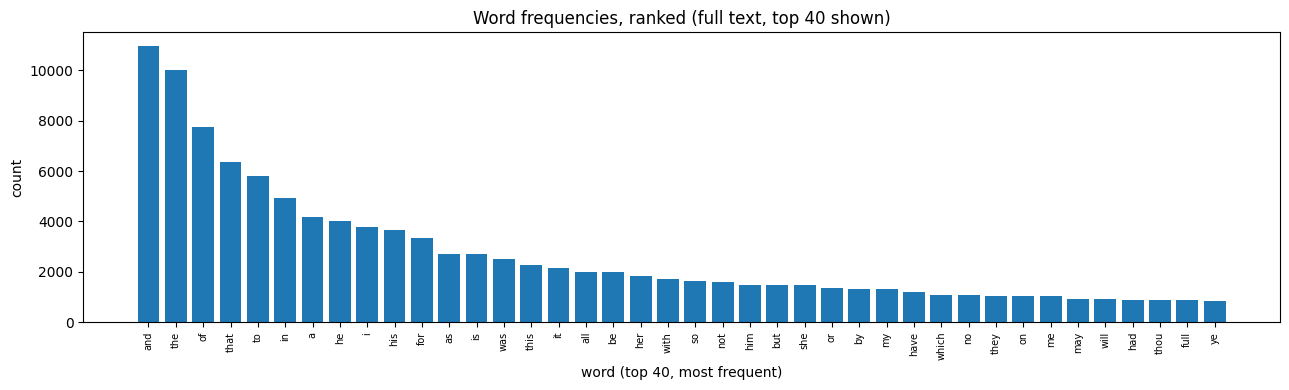

In [32]:
# Load the full text from GitHub and count its words the same way as before.
# It goes into NEW variables (full_text, full_text_counts), so the small example above still works.
from collections import Counter
import urllib.request
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/christiancasey/measuring-manuscripts/refs/heads/main/Workbook/Day%200%20Teaser%E2%80%94What%20is%20Computational%20Philology/Canterbury%20Tales.txt"
full_text = urllib.request.urlopen(url).read().decode("utf-8")

full_words = full_text.split()
full_text_counts = Counter(w.lower().strip('.,;') for w in full_words)
print(f'Loaded {len(full_words):,} words, {len(full_text_counts):,} distinct.')

# Rank from most to least frequent
full_ranked = full_text_counts.most_common()
full_labels = [word for word, n in full_ranked]
full_values = [n for word, n in full_ranked]

# Tens of thousands of distinct words is far too many to label, so show only the top 40.
TOP = 40
plt.figure(figsize=(13, 4))
plt.bar(range(TOP), full_values[:TOP])
plt.xticks(range(TOP), full_labels[:TOP], rotation=90, fontsize=7)
plt.xlabel('word (top 40, most frequent)')
plt.ylabel('count')
plt.title('Word frequencies, ranked (full text, top 40 shown)')
plt.tight_layout()
plt.show()

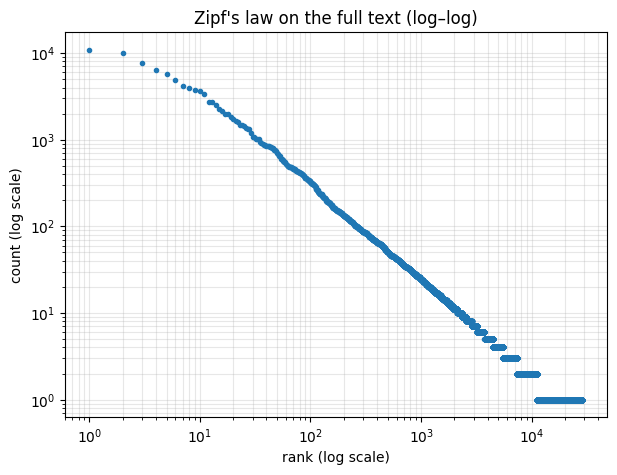

In [33]:
# The full distribution on log–log axes. Now the Zipf line is clear.
import numpy as np

full_ranks = np.arange(1, len(full_values) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(full_ranks, full_values, marker='.', linestyle='none')
plt.xlabel('rank (log scale)')
plt.ylabel('count (log scale)')
plt.title("Zipf's law on the full text (log–log)")
plt.grid(True, which='both', alpha=0.3)
plt.show()

#### Digging into the data

Let's try to answer the questions above using statistical approaches.

Don't worry right now about what this does exactly. Just run it and look at the figure it outputs.

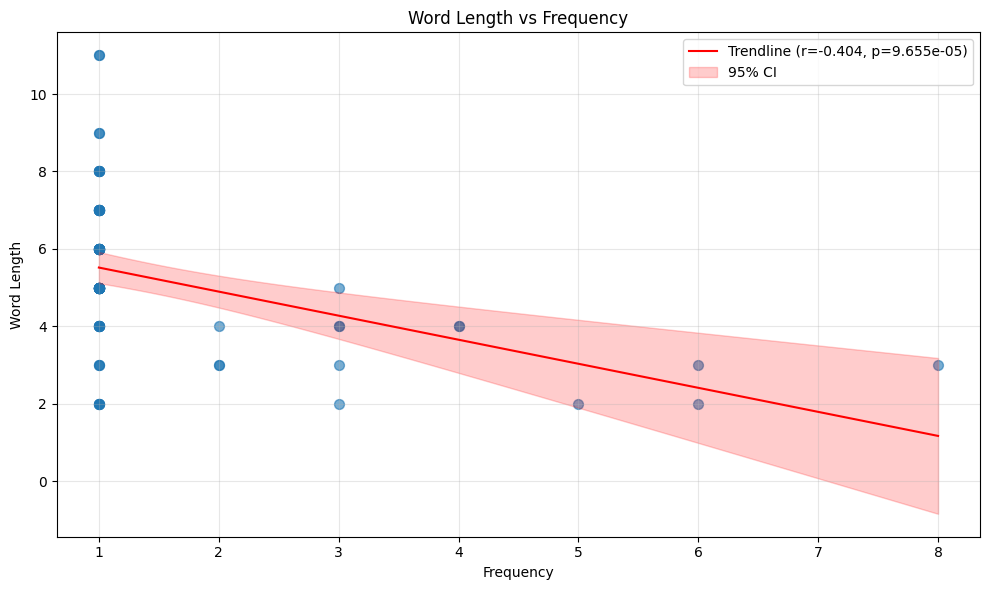

r = -0.4036
p = 9.6545e-05

Trendline equation: length = -0.620712 * freq + 6.141491


In [41]:
# Let's do some quantitative and statistical analysis

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

lengths = [len(word) for word in counts]
freq = [n for n in counts.values()]

# Regress word length on frequency (word length is now the y variable)
slope, intercept, r_value, p_value, std_err = stats.linregress(freq, lengths)

# Trendline predictions across the frequency range
x_line = np.array([min(freq), max(freq)])
y_line = slope * x_line + intercept

# Calculate 95% confidence intervals
n = len(freq)
dof = n - 2
t_val = stats.t.ppf(0.975, dof)
s_err = np.sqrt(np.sum((np.array(lengths) - (slope * np.array(freq) + intercept))**2) / dof)
x_mean = np.mean(freq)
x_range = np.linspace(min(freq), max(freq), 100)
se = s_err * np.sqrt(1/n + (x_range - x_mean)**2 / np.sum((np.array(freq) - x_mean)**2))
ci_upper = slope * x_range + intercept + t_val * se
ci_lower = slope * x_range + intercept - t_val * se

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(freq, lengths, alpha=0.6, s=50)
plt.plot(x_line, y_line, 'r-', label=f'Trendline (r={r_value:.3f}, p={p_value:.3e})')
plt.fill_between(x_range, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI')
plt.xlabel('Frequency')
plt.ylabel('Word Length')
plt.title('Word Length vs Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'r = {r_value:.4f}')
print(f'p = {p_value:.4e}')
print(f'\nTrendline equation: length = {slope:.6f} * freq + {intercept:.6f}')

That's interesting, but still a bit unclear. What if we do the same with the full Prologue?

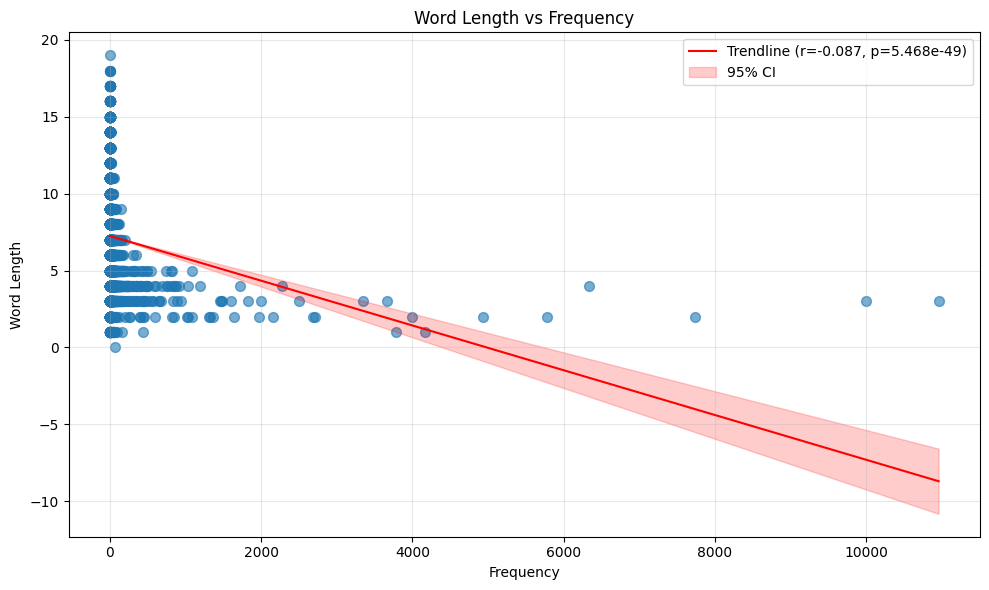

r = -0.0865
p = 5.4685e-49

Trendline equation: length = -0.001455 * freq + 7.253763


In [42]:
# Full text: word length vs frequency

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

lengths = [len(word) for word in full_text_counts]
freq = [n for n in full_text_counts.values()]

# Regress word length on frequency (word length is now the y variable)
slope, intercept, r_value, p_value, std_err = stats.linregress(freq, lengths)

# Trendline predictions across the frequency range
x_line = np.array([min(freq), max(freq)])
y_line = slope * x_line + intercept

# Calculate 95% confidence intervals
n = len(freq)
dof = n - 2
t_val = stats.t.ppf(0.975, dof)
s_err = np.sqrt(np.sum((np.array(lengths) - (slope * np.array(freq) + intercept))**2) / dof)
x_mean = np.mean(freq)
x_range = np.linspace(min(freq), max(freq), 100)
se = s_err * np.sqrt(1/n + (x_range - x_mean)**2 / np.sum((np.array(freq) - x_mean)**2))
ci_upper = slope * x_range + intercept + t_val * se
ci_lower = slope * x_range + intercept - t_val * se

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(freq, lengths, alpha=0.6, s=50)
plt.plot(x_line, y_line, 'r-', label=f'Trendline (r={r_value:.3f}, p={p_value:.3e})')
plt.fill_between(x_range, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI')
plt.xlabel('Frequency')
plt.ylabel('Word Length')
plt.title('Word Length vs Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'r = {r_value:.4f}')
print(f'p = {p_value:.4e}')
print(f'\nTrendline equation: length = {slope:.6f} * freq + {intercept:.6f}')

Now the relationship is much stronger, but also clearly not linear, and it feels like we could do this better somehow. The data we have now show that something interesting is going on, but without some deeper theory, it's hard to say what it is.

We'll discuss another way to think about this in Class 6.

## 3. Your turn

Paste any text you like between the triple quotes and run the cell.

In [36]:
my_text = """
PASTE SOME TEXT HERE
"""
print('You pasted', len(my_text.split()), 'words.')

You pasted 4 words.


✅ If everything above ran, you're set. See you on Day 1.

## 4. (Optional) List the five most frequent words in your text

Reverse engineer the above code and recreate it for your own text.

In [37]:
# counts =